Test the delta_v hypothesis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.utils.plotting import plot_position_sitnikov


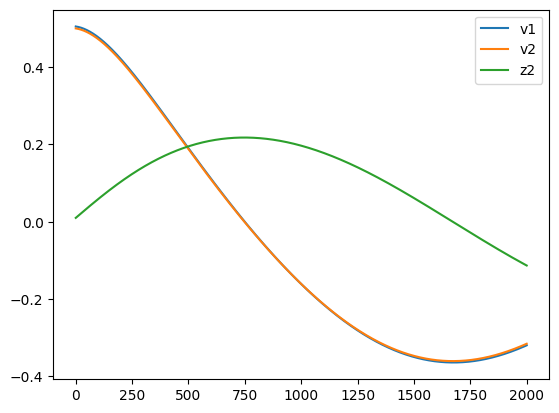

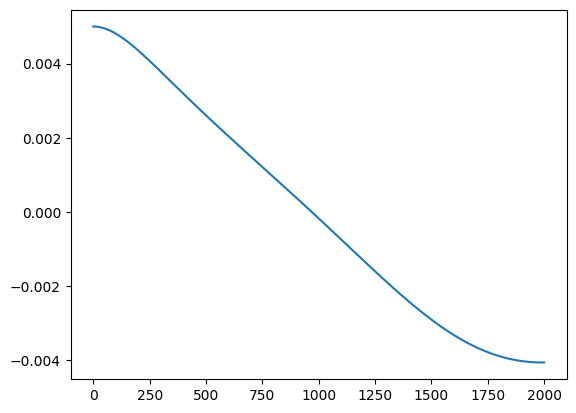

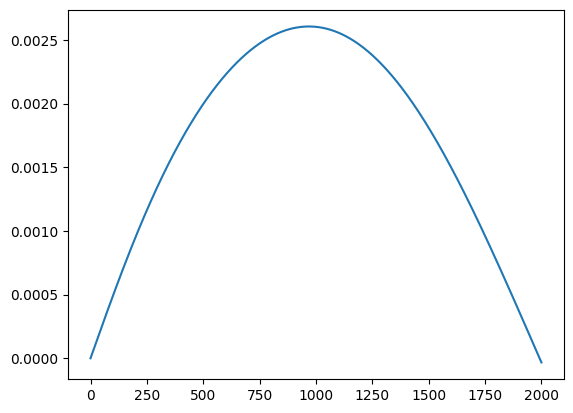

In [22]:
from src.integrator.integrate import FastSitnikovSimulation
e = 0.5
sim = FastSitnikovSimulation(e = e)
z0 = 0.01
v1 = 0.505
v2 = 0.5
t0 = 1.0
T = 2.0
dt = 0.001

z_arr1, v_arr1 = sim.trajectory_fast(z0 = z0, vz0 = v1, t0 = t0, T = T, dt = dt)
z_arr2, v_arr2 = sim.trajectory_fast(z0 = z0, vz0 = v2, t0 = t0, T = T, dt = dt)

plt.plot(np.arange(len(v_arr1)), v_arr1, label = "v1")
plt.plot(np.arange(len(v_arr1)), v_arr2, label = "v2")
plt.plot(np.arange(len(v_arr1)), z_arr2, label = "z2")
plt.legend()
plt.show()

plt.plot(np.arange(len(v_arr1)), v_arr1 - v_arr2)
plt.show()
plt.plot(np.arange(len(v_arr1)), z_arr1 - z_arr2)
plt.show()


The above cell establishes that it isn't true that delta_v is increasing

Let's check if the return time is an increasing function

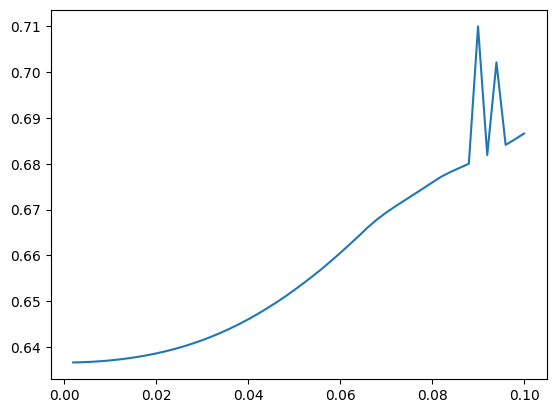

In [31]:
e = 0.99
sim = FastSitnikovSimulation(e = e)
t0 = -1.0
v_max = 0.1
N = 50
T_ret_arr = np.zeros(N)
v_arr = np.arange(1,N+1)*v_max/N
for i, v in enumerate(v_arr):
    T_ret_arr[i] = sim.phi_fast(v=v, t=t0, return_mod_period=False)[1] - t0

plt.plot(v_arr, T_ret_arr)